# Layer 1; 32; 3x3; AvgPool

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


## Import Libraries

In [2]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

2026-05-13 13:32:52.716724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778679173.120420      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778679173.230946      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778679174.237625      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679174.237663      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778679174.237666      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


True

## Config

In [3]:
TRAIN_DIR  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
VAL_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
TEST_DIR   = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'
MODEL_DIR = '/kaggle/working/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778679219.693911      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778679219.699892      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11228 gambar
Validation : 2806 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [5]:
MODEL_NAME = 'Layer-2-64-128-5x5-maxpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(64, (5, 5), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_1'),
    keras.layers.Conv2D(128, (5, 5), activation='relu', padding='valid', name='conv2s_2'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_2'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

Model: "Layer-2-64-128-5x5-maxpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 146, 146, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2s_2 (Conv2D)               │ (None, 69, 69, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    18,940,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,150,598 (73.05 MB)

 Trainable params: 19,150,598 (73.05 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'/kaggle/working/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/10


I0000 00:00:1778679274.908801     136 service.cc:152] XLA service 0x7ef8380040d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778679274.908834     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778679274.908837     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778679275.309295     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-13 13:34:41.415292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 13:34:41.601535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/176 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.1797 - loss: 1.9768 

I0000 00:00:1778679285.578511     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


156/176 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4703 - loss: 1.3467

...

176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.4827 - loss: 1.3177 - val_accuracy: 0.6971 - val_loss: 0.7972
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7170 - loss: 0.7712
Epoch 2: val_loss improved from 0.79719 to 0.64541, saving model to /kaggle/working/models/cnn/Layer-2-64-128-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.7170 - loss: 0.7711 - val_accuracy: 0.7587 - val_loss: 0.6454
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7641 - loss: 0.6459
Epoch 3: val_loss improved from 0.64541 to 0.27947, saving model to /kaggle/working/models/cnn/Layer-2-64-128-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.7642 - loss: 0.6458 - val_accuracy: 0.9163 - val_loss: 0.2795
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8110 - loss: 0.5442
Epoch 4: val_loss did not improve from 0.27947
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8110 - loss: 0.5442 - val_accuracy: 0.8368 - val_loss: 0.4909
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8523 - loss: 0.4422
Epoch 5: val_loss did not improve from 0.27947
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.8522 - loss: 0.4423 - val_accuracy: 0.8909 - val_loss: 0.3531
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8765 - loss: 0.3751
Epoch 6: val_loss did not improve from 0.27947
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.8764 - loss: 0.3752 - val_accuracy: 0.9063 - val_loss: 0.3171
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8953 - loss: 0.3230
Epoch 7: val_loss did not i

176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9097 - loss: 0.2834 - val_accuracy: 0.9155 - val_loss: 0.2671
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9321 - loss: 0.2302
Epoch 9: val_loss improved from 0.26711 to 0.15508, saving model to /kaggle/working/models/cnn/Layer-2-64-128-5x5-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.9321 - loss: 0.2302 - val_accuracy: 0.9505 - val_loss: 0.1551
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9383 - loss: 0.2000
Epoch 10: val_loss did not improve from 0.15508
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9383 - loss: 0.2000 - val_accuracy: 0.9134 - val_loss: 0.2748
Restoring model weights from the end of the best epoch: 9.


## Evaluation

In [7]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step
Macro F1 Score: 0.7674


## Plot

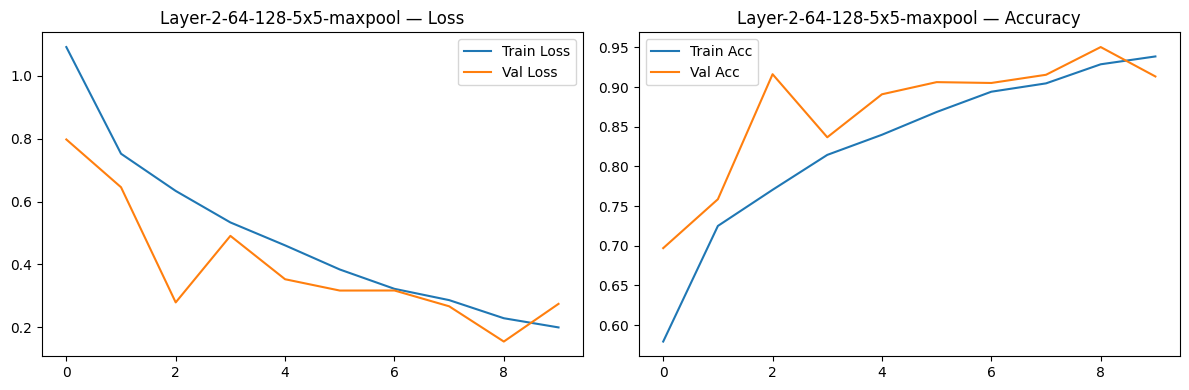

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()

In [9]:
# import shutil
# shutil.make_archive('hasil_output', 'zip', '/kaggle/working/models/')

# # Membuat link download langsung di notebook
# from IPython.display import FileLink
# FileLink(r'hasil_output.zip')